<a href="https://colab.research.google.com/github/diwakarg05/Neural-Network/blob/main/4_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download("guillemservera/grains-and-cereals-futures")

# Check files
print(os.listdir(path))

# Load correct file
file_path = os.path.join(path, "all_grains_data.csv")
df = pd.read_csv(file_path)

print(df.head())

100%|██████████| 919k/919k [00:00<00:00, 35.7MB/s]

Extracting files...
['all_grains_data.csv', 'individual_data']
  ticker commodity        date    open    high     low   close  volume
0   ZC=F      Corn  2000-07-17  182.25  182.25  178.25  179.25   19385
1   ZC=F      Corn  2000-07-18  179.00  183.25  179.00  180.75   25205
2   ZC=F      Corn  2000-07-19  180.00  182.75  178.75  182.00   17126
3   ZC=F      Corn  2000-07-20  181.50  187.00  181.00  186.00   18742
4   ZC=F      Corn  2000-07-21  185.50  188.00  185.00  187.75   16814


In [ ]:
# Drop non-numeric columns (like Date)
df = df.select_dtypes(include=['float64', 'int64'])

# Fill missing values
df = df.fillna(df.mean())

print(df.head())
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

     open    high     low   close  volume
0  182.25  182.25  178.25  179.25   19385
1  179.00  183.25  179.00  180.75   25205
2  180.00  182.75  178.75  182.00   17126
3  181.50  187.00  181.00  186.00   18742
4  185.50  188.00  185.00  187.75   16814


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(32, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))  # regression output

model.compile(optimizer='adam', loss='mse')

history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1442/1442 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 3579249664.0000 - val_loss: 3533802496.0000
Epoch 2/50
1442/1442 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 3314993920.0000 - val_loss: 3221676800.0000
Epoch 3/50
1442/1442 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 3093890304.0000 - val_loss: 3116503040.0000
Epoch 4/50
1442/1442 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 3033569280.0000 - val_loss: 3079437824.0000
Epoch 5/50
1442/1442 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2986162944.0000 - val_loss: 3019462400.0000
Epoch 6/50
1442/1442 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2926497536.0000 - val_loss: 2967720448.0000
Epoch 7/50
1442/1442 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2882784256.0000 - val_loss: 2932891904.0000
Epoch 8/50
1442/1442 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 2848949504.0000 - val_loss: 2902989824.0000
Epoch 9/50
1442/1442 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 2821049600.0000 - val_loss: 2880744960.0000
Epoch 10/50
1442/1442 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - 

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R² Score:", r2)

226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MSE: 2798586368.0
R² Score: 0.02374821901321411


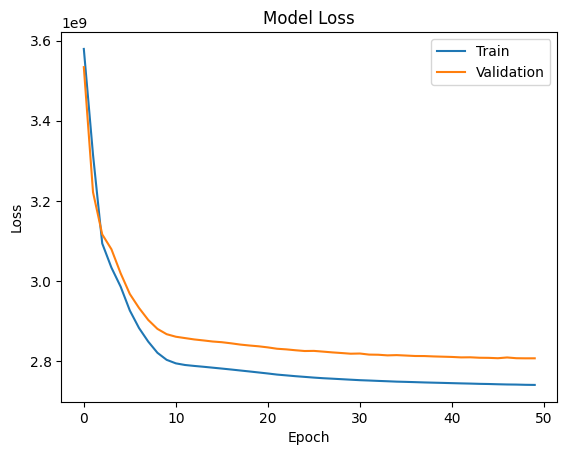

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()